
# OAM focusing: masks

This notebook:
1. sets the parameters,
2. finds the optimal $\beta$,
3. builds the three masks (optimal, PFBZ, FBZ), and
4. plots their amplitudes and binary phases.



In [1]:


import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv
from scipy.optimize import minimize_scalar
import pandas as pd

plt.rcParams['figure.dpi'] = 140
np.set_printoptions(precision=6, suppress=True)

In [ ]:
# -----------------------------
# Parameters
# -----------------------------
l = 3
n0 = 10

pixel_pitch= 20e-6           # pixel pitch [m]

slm_x_res = 800                # SLM horizontal resolution [px]
slm_y_res = 600                # SLM vertical resolution [px]

slm_x_size = pixel_pitch * slm_x_res  # SLM horizontal size [m]
slm_y_size = pixel_pitch * slm_y_res  # SLM vertical size [m]

a = 3e-3                 # aperture radius [m]
a_px = a / pixel_pitch  # aperture radius in pixels

Nrho_in = 4000           # radial grid for mask construction
rho_beta_points = 40001  # radial grid for beta optimization
beta_search_max = 20.0

rho_beta = np.linspace(0.0, 1.0, rho_beta_points)
rho_in = np.linspace(0.0, 1.0, Nrho_in)

tau_f = 1.0 / (2.0 * np.pi * n0)

print(f'aperture pixels = {a_px:.3f} px')
print(f'aperture radius = {1000*a:.3f} mm')

print(f'slm_x_size = {1000*slm_x_size:.6f} mm')
print(f'slm_y_size = {1000*slm_y_size:.6f} mm')

print(f'l      = {l}')
print(f'n0     = {n0}')
print(f'tau_f  = {tau_f:.9f}')

aperture pixels = 150.000 px
aperture radius = 3.000 mm
slm_x_size = 16.000000 mm
slm_y_size = 12.000000 mm
l      = 0
n0     = 10
tau_f  = 0.015915494


In [3]:
# -----------------------------
# Beta optimization
# -----------------------------
def I0_of_beta(beta):
    J = jv(l, beta * rho_beta)
    return np.trapezoid(rho_beta * J**2, rho_beta) / (2.0 * np.pi)


def R_of_beta(beta):
    J = jv(l, beta * rho_beta)
    phase = np.exp(1j * rho_beta**2 / tau_f)
    return np.trapezoid(rho_beta * J**2 * phase, rho_beta) / (2.0 * np.pi)


def lambda_plus(beta):
    I0 = I0_of_beta(beta)
    R = R_of_beta(beta)
    return (I0 + np.abs(R)) / (2.0 * tau_f**2)


opt = minimize_scalar(
    lambda b: -lambda_plus(b),
    bounds=(1e-4, beta_search_max),
    method='bounded',
    options={'xatol': 1e-6}
)

beta_opt = float(opt.x)
lambda_opt = float(lambda_plus(beta_opt))

print(f'beta_opt   = {beta_opt:.9f}')
print(f'lambda_opt = {lambda_opt:.9f}')


beta_opt   = 0.000100599
lambda_opt = 157.079634351


In [4]:

# -----------------------------
# Build the masks
# -----------------------------
J_beta = jv(l, beta_opt * rho_in)

I0_beta = np.trapezoid(rho_in * J_beta**2, rho_in) / (2.0 * np.pi)
R_beta = np.trapezoid(
    rho_in * J_beta**2 * np.exp(1j * rho_in**2 / tau_f),
    rho_in
) / (2.0 * np.pi)

theta = 0.5 * np.angle(R_beta)
phase_arg = rho_in**2 / (2.0 * tau_f) - theta


def normalize_pupil(psi_raw, rho):
    norm = np.sqrt(2.0 * np.pi * np.trapezoid(rho * np.abs(psi_raw)**2, rho))
    psi = psi_raw / norm
    norm_check = 2.0 * np.pi * np.trapezoid(rho * np.abs(psi)**2, rho)
    return psi, norm_check


def binary_pm_one(expr):
    # Strict ±1 convention so zeros do not appear as isolated 0-valued pixels.
    return np.where(expr >= 0.0, 1.0, -1.0)


# Optimal pupil
psi_opt_raw = J_beta * np.cos(phase_arg)
psi_opt, norm_opt = normalize_pupil(psi_opt_raw, rho_in)

# PFBZ pupil
expr_pfbz = J_beta * np.cos(phase_arg)
psi_pfbz_raw = (2.0 * np.sqrt(np.pi)) * binary_pm_one(expr_pfbz)
psi_pfbz, norm_pfbz = normalize_pupil(psi_pfbz_raw, rho_in)

# FBZ pupil
expr_fbz = np.cos(phase_arg)
psi_fbz_raw = (J_beta / np.sqrt(I0_beta)) * binary_pm_one(expr_fbz)
psi_fbz, norm_fbz = normalize_pupil(psi_fbz_raw, rho_in)

rho_star = beta_opt * tau_f
r_star = a * rho_star

print(f'theta       = {theta:.9f} rad')
print(f'rho_star    = {rho_star:.9f}')
print(f'r_star      = {1e3 * r_star:.6f} mm')
print(f'I0(betaopt) = {I0_beta:.9f}')
print()
print(f'opt  norm check = {norm_opt:.12f}')
print(f'PFBZ norm check = {norm_pfbz:.12f}')
print(f'FBZ  norm check = {norm_fbz:.12f}')


theta       = 0.785397771 rad
rho_star    = 0.000001601
r_star      = 0.000005 mm
I0(betaopt) = 0.079577471

opt  norm check = 1.000000000000
PFBZ norm check = 1.000000000000
FBZ  norm check = 1.000000000000


In [5]:

# -----------------------------
# Mask specifications for display/export
# -----------------------------
J_beta_max = np.max(np.abs(J_beta))
opt_amp_max = np.max(np.abs(psi_opt_raw))


def opt_expr(r):
    return jv(l, beta_opt * r) * np.cos(r**2 / (2.0 * tau_f) - theta)


def fbz_expr(r):
    return np.cos(r**2 / (2.0 * tau_f) - theta)


def mask_opt_sign_func(r):
    return binary_pm_one(opt_expr(r))


def mask_pfbz_sign_func(r):
    return binary_pm_one(opt_expr(r))


def mask_fbz_sign_func(r):
    return binary_pm_one(fbz_expr(r))


def mask_opt_amp_func(r):
    return opt_expr(r) / opt_amp_max


def mask_pfbz_amp_func(r):
    return mask_pfbz_sign_func(r)


def mask_fbz_amp_func(r):
    return jv(l, beta_opt * r) * mask_fbz_sign_func(r) / J_beta_max


mask_opt_sign = mask_opt_sign_func(rho_in)
mask_pfbz_sign = mask_pfbz_sign_func(rho_in)
mask_fbz_sign = mask_fbz_sign_func(rho_in)

mask_opt_amp = mask_opt_amp_func(rho_in)
mask_pfbz_amp = mask_pfbz_amp_func(rho_in)
mask_fbz_amp = mask_fbz_amp_func(rho_in)

print('Amplitude ranges:')
print('  optimal :', float(np.min(mask_opt_amp)), float(np.max(mask_opt_amp)))
print('  PFBZ    :', float(np.min(mask_pfbz_amp)), float(np.max(mask_pfbz_amp)))
print('  FBZ     :', float(np.min(mask_fbz_amp)), float(np.max(mask_fbz_amp)))

Amplitude ranges:
  optimal : -0.9999999839200254 1.0
  PFBZ    : -1.0 1.0
  FBZ     : -0.9999999998099595 1.0


In [6]:

# -----------------------------
# Plot helpers
# -----------------------------
def radial_spec_to_2d(spec, rho_samples, R):
    if callable(spec):
        return spec(R)
    return np.interp(R, rho_samples, np.asarray(spec), left=0.0, right=0.0)


def plot_mask_amplitude_2d(mask_spec, rho_samples, title, N=400):
    x = np.linspace(-1.0, 1.0, N)
    y = np.linspace(-1.0, 1.0, N)
    X, Y = np.meshgrid(x, y)
    R = np.sqrt(X**2 + Y**2)

    amp_2d = radial_spec_to_2d(mask_spec, rho_samples, R)
    amp_2d = np.clip(amp_2d, -1.0, 1.0)

    ####################################
    #FARID
    # amp_masked = np.ma.masked_where(R > 1.0, amp_2d)
    ####################################
    ####################################
    #Lukas

    amp_masked = np.where(R > 1.0, 0.0, amp_2d)

    target_h, target_w = 600, 800
    current_h, current_w = amp_masked.shape

    pad_h = max(0, target_h - current_h)
    pad_w = max(0, target_w - current_w)

    pad_top = pad_h // 2
    pad_bottom = pad_h - pad_top
    pad_left = pad_w // 2
    pad_right = pad_w - pad_left

    amp_masked = np.pad(amp_masked, 
                          ((pad_top, pad_bottom), (pad_left, pad_right)), 
                          mode='constant', 
                          constant_values=0)
    
    ####################################

    fig, ax = plt.subplots(figsize=(8, 6))
    cmap = plt.cm.RdBu_r.copy()
    cmap.set_bad(color='white')

    im = ax.imshow(
        amp_masked,
        origin='lower',
        extent=[-1, 1, -1, 1],
        cmap=cmap,
        interpolation='nearest',
        vmin=-1.0,
        vmax=1.0
    )

    ax.set_aspect('auto')
    ax.set_title(title)
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$y$')
    ax.set_xticks([-1, 0, 1])
    ax.set_yticks([-1, 0, 1])

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, shrink=0.82)
    cbar.set_label('amplitude')
    cbar.set_ticks([-1, 0, 1])

    plt.tight_layout()
    plt.show()

    ####################   convert to hologram

    magnitudes = np.abs(amp_masked)
    phases = np.where(amp_masked < 0, np.pi, 0)

    amp_masked = magnitudes * np.exp(1j * phases)

    print(amp_masked)


    return amp_masked


def plot_binary_phase_2d(mask_sign_spec, rho_samples, title, N=400):
    x = np.linspace(-1.0, 1.0, N)
    y = np.linspace(-1.0, 1.0, N)
    X, Y = np.meshgrid(x, y)
    R = np.sqrt(X**2 + Y**2)

    sign_2d = radial_spec_to_2d(mask_sign_spec, rho_samples, R)
    sign_2d = np.where(sign_2d >= 0.0, 1.0, -1.0)

    # Display as a standard 0/pi binary phase mask.
    phase_2d = np.where(sign_2d >= 0.0, 0.0, np.pi)
    
    ####################################
    #Farid
    # phase_masked = np.ma.masked_where(R > 1.0, phase_2d)
    ####################################
    ####################################
    #Lukas
    phase_masked = np.where(R > 1.0, 0.0, phase_2d)

    target_h, target_w = 600, 800
    current_h, current_w = phase_masked.shape

    pad_h = max(0, target_h - current_h)
    pad_w = max(0, target_w - current_w)

    pad_top = pad_h // 2
    pad_bottom = pad_h - pad_top
    pad_left = pad_w // 2
    pad_right = pad_w - pad_left

    phase_masked = np.pad(phase_masked, 
                          ((pad_top, pad_bottom), (pad_left, pad_right)), 
                          mode='constant', 
                          constant_values=0)
    
    ####################################
    

    fig, ax = plt.subplots(figsize=(8, 6))
    cmap = plt.cm.RdBu_r.copy()
    cmap.set_bad(color='white')

    im = ax.imshow(
        phase_masked,
        origin='lower',
        extent=[-1, 1, -1, 1],
        cmap=cmap,
        interpolation='nearest',
        vmin=0.0,
        vmax=np.pi
    )

    ax.set_aspect('auto')
    ax.set_title(title)
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$y$')
    ax.set_xticks([-1, 0, 1])
    ax.set_yticks([-1, 0, 1])

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, shrink=0.82)
    cbar.set_label('phase [rad]')
    cbar.set_ticks([0.0, np.pi])
    cbar.set_ticklabels(['0', r'$\pi$'])

    plt.tight_layout()
    plt.show()

    
    return phase_masked



In [7]:
import pandas as pd

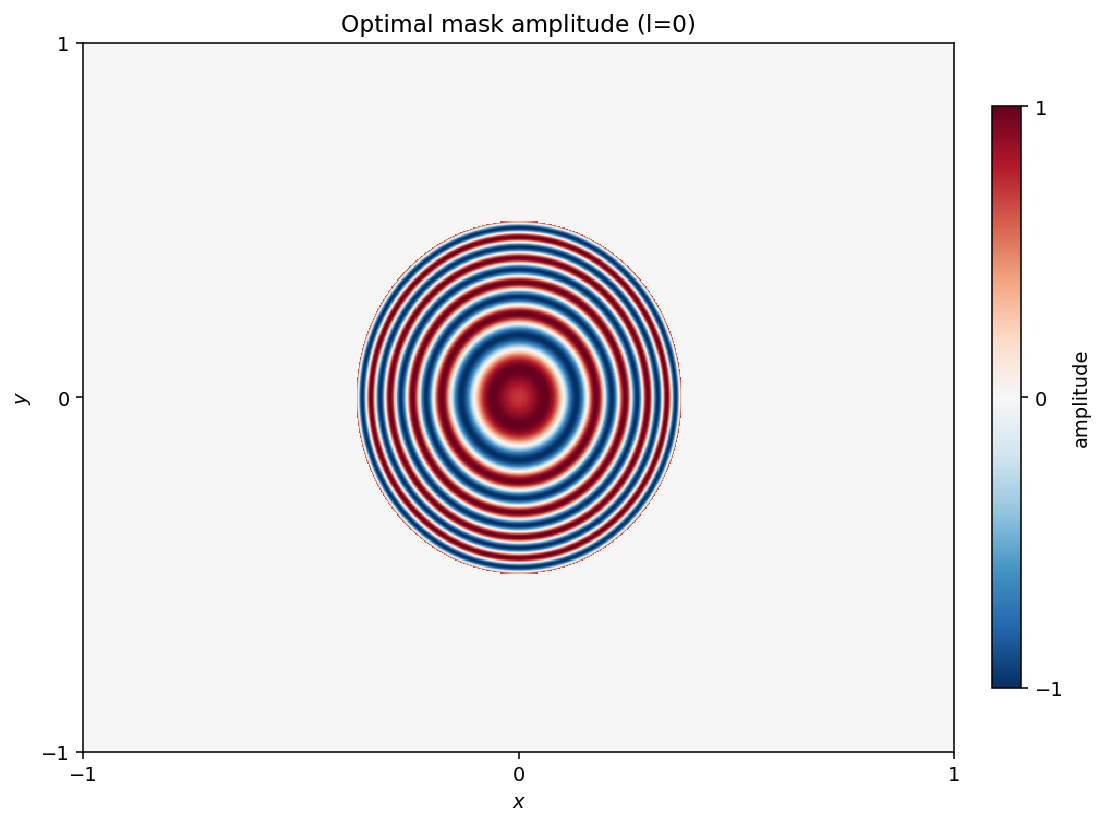

[[0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 ...
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]]


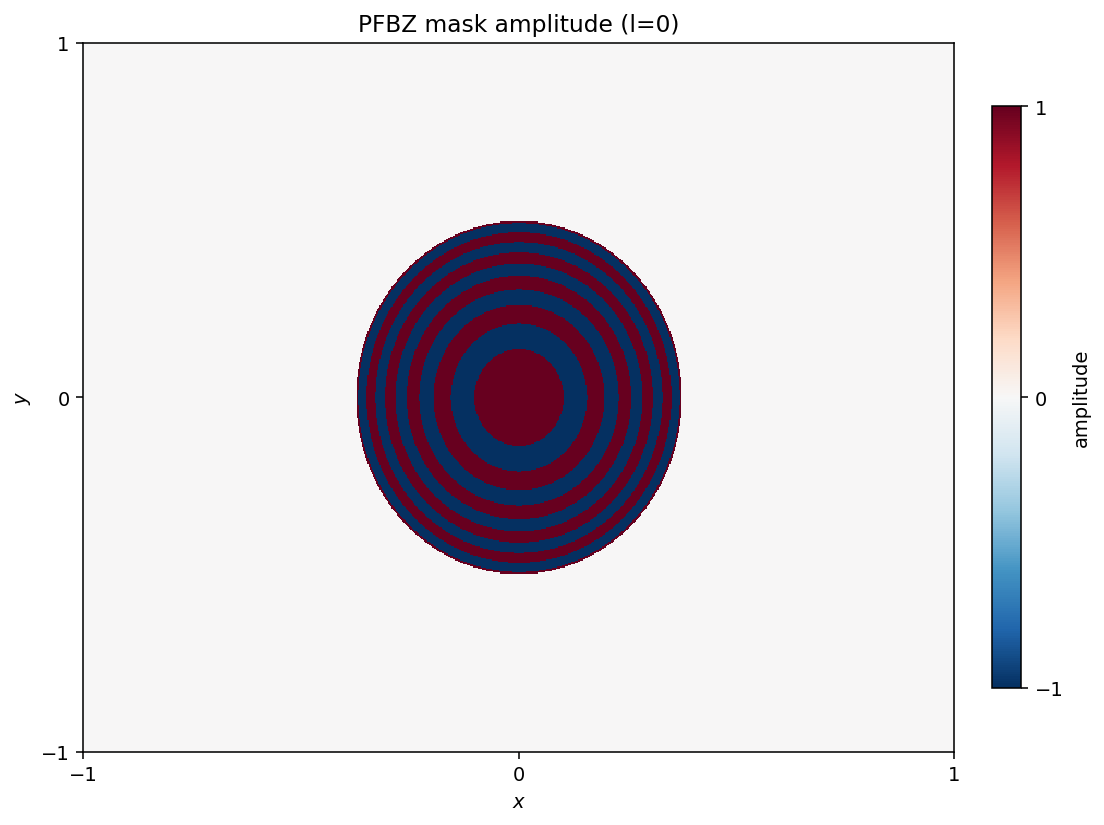

[[0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 ...
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]]


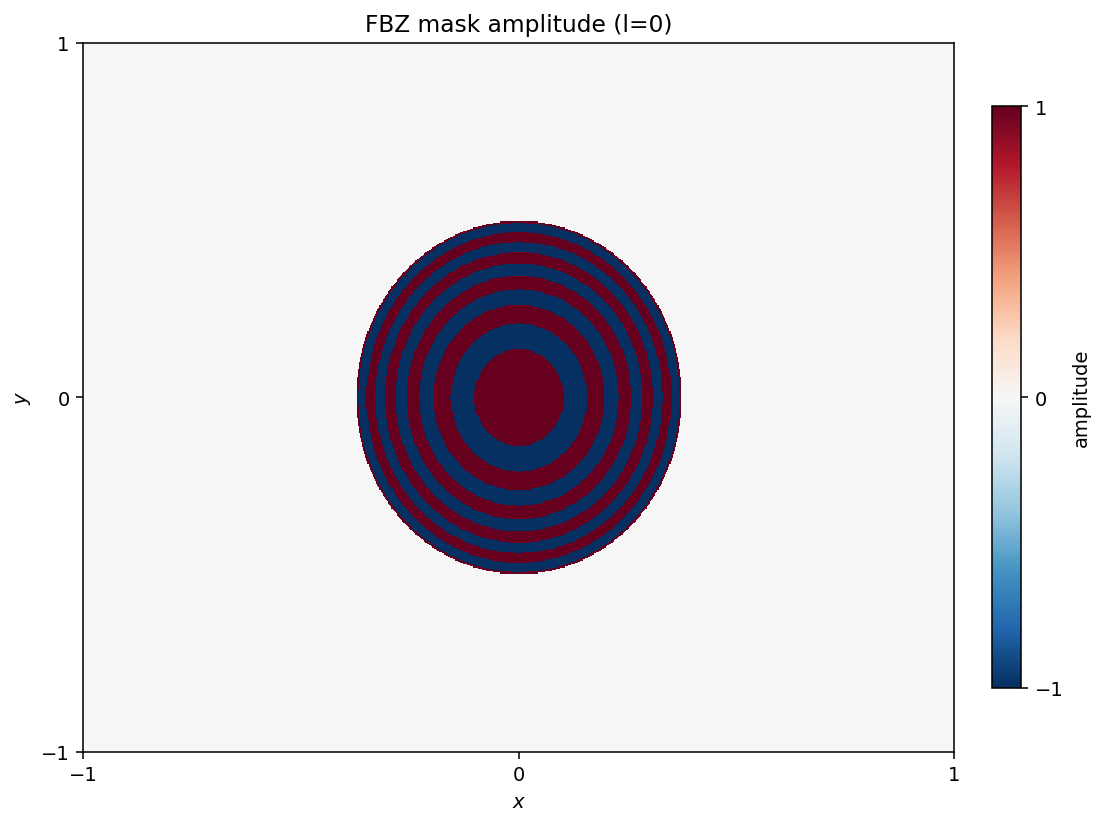

[[0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 ...
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]]


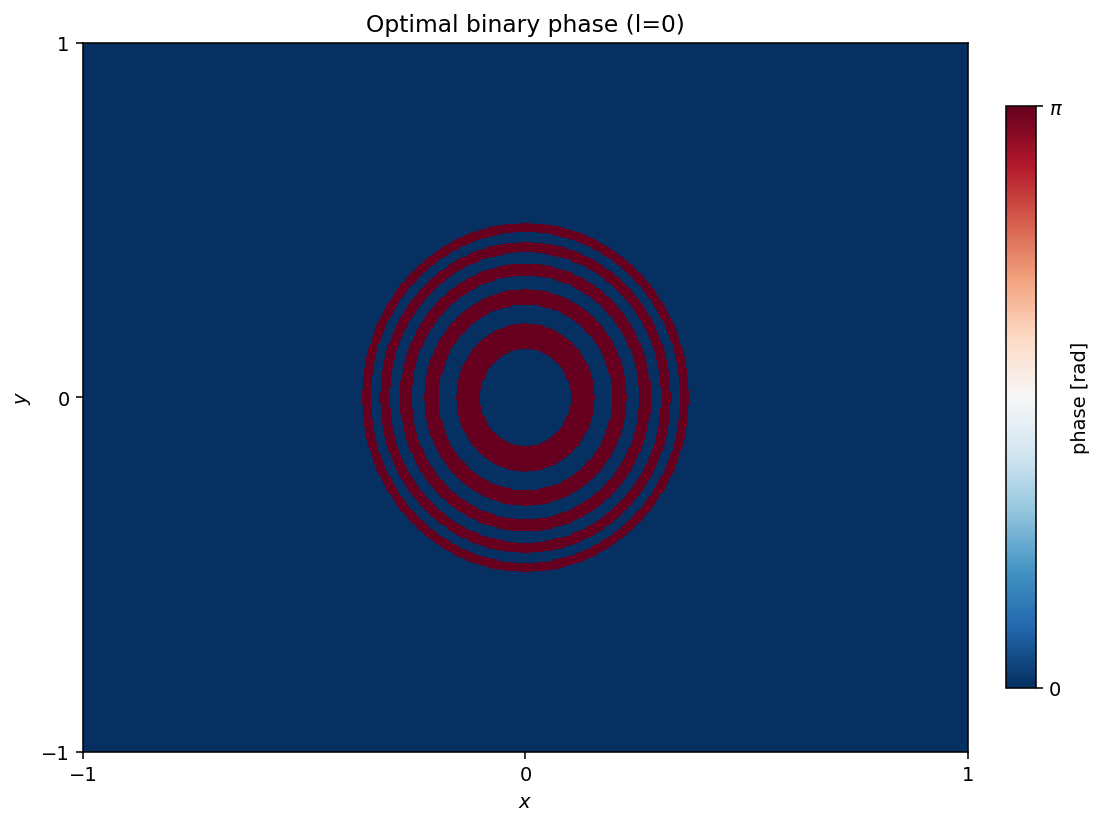

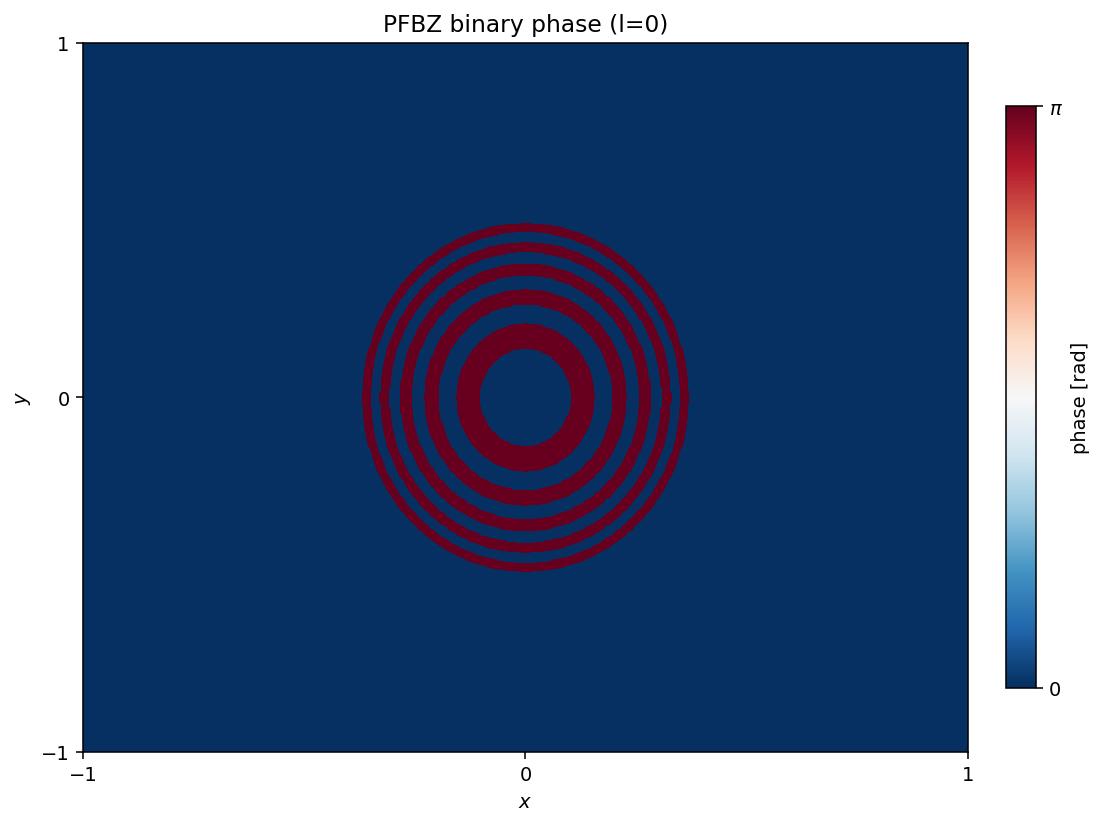

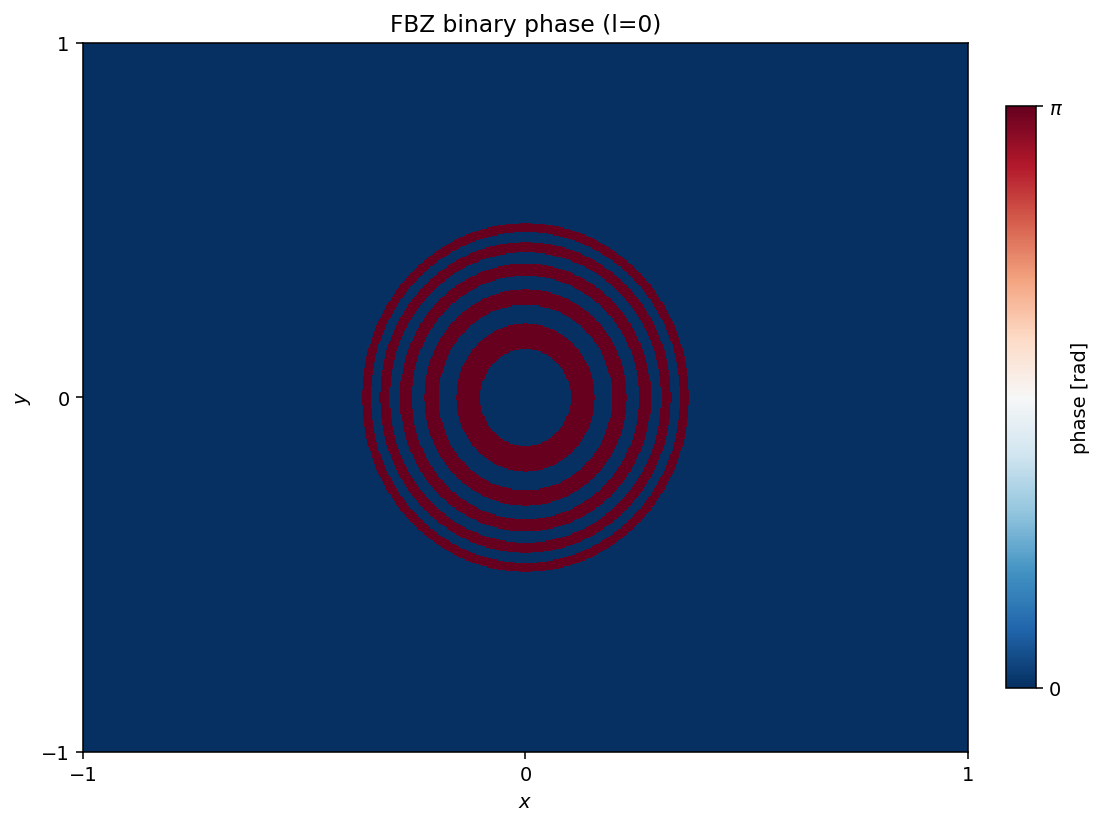

In [8]:
# -----------------------------
# Mask plots
# -----------------------------
opt_amp_mask=plot_mask_amplitude_2d(mask_opt_amp_func,  rho_in, f'Optimal mask amplitude (l={l})',N=int(2*a_px))
opt_amp_mask_flat = opt_amp_mask.flatten()
opt_amp_mask = pd.DataFrame({
    'Real': opt_amp_mask_flat.real,
    'Imaginary': opt_amp_mask_flat.imag
})
opt_amp_mask.to_csv("opt_amp_mask.csv", index=False, header=False)

pfbz_amp_mask=plot_mask_amplitude_2d(mask_pfbz_amp_func, rho_in, f'PFBZ mask amplitude (l={l})',N=int(2*a_px))
pfbz_amp_mask_flat = pfbz_amp_mask.flatten()
pfbz_amp_mask = pd.DataFrame({
    'Real': pfbz_amp_mask_flat.real,
    'Imaginary': pfbz_amp_mask_flat.imag
})
pfbz_amp_mask.to_csv("pfbz_amp_mask.csv", index=False, header=False)


fbz_amp_mask=plot_mask_amplitude_2d(mask_fbz_amp_func,  rho_in, f'FBZ mask amplitude (l={l})',N=int(2*a_px))
fbz_amp_mask_flat = fbz_amp_mask.flatten()
fbz_amp_mask = pd.DataFrame({
    'Real': fbz_amp_mask_flat.real,
    'Imaginary': fbz_amp_mask_flat.imag
})
fbz_amp_mask.to_csv("fbz_amp_mask.csv", index=False, header=False)


opt_sign_mask=plot_binary_phase_2d(mask_opt_sign_func,  rho_in, f'Optimal binary phase (l={l})',N=int(2*a_px))
opt_sign_mask_flat = opt_sign_mask.flatten()
opt_sign_mask = pd.DataFrame({
    'Real': opt_sign_mask_flat.real,
    'Imaginary': opt_sign_mask_flat.imag
})
opt_sign_mask.to_csv("opt_sign_mask.csv", index=False, header=False)


pfbz_sign_mask=plot_binary_phase_2d(mask_pfbz_sign_func, rho_in, f'PFBZ binary phase (l={l})',N=int(2*a_px))
pfbz_sign_mask_flat = pfbz_sign_mask.flatten()
pfbz_sign_mask = pd.DataFrame({
    'Real': pfbz_sign_mask_flat.real,
    'Imaginary': pfbz_sign_mask_flat.imag
})
pfbz_sign_mask.to_csv("pfbz_sign_mask.csv", index=False, header=False)


fbz_sign_mask=plot_binary_phase_2d(mask_fbz_sign_func,  rho_in, f'FBZ binary phase (l={l})',N=int(2*a_px))
fbz_sign_mask_flat = fbz_sign_mask.flatten()
fbz_sign_mask = pd.DataFrame({
    'Real': fbz_sign_mask_flat.real,
    'Imaginary': fbz_sign_mask_flat.imag
})
fbz_sign_mask.to_csv("fbz_sign_mask.csv", index=False, header=False)

In [9]:

# -----------------------------
# Optional: save the 1D radial masks and metadata
# -----------------------------
outfile = f'oam_masks_only_l{l}_n0{n0}.npz'

np.savez(
    outfile,
    l=l,
    n0=n0,
    tau_f=tau_f,
    beta_opt=beta_opt,
    theta=theta,
    rho_star=rho_star,
    r_star=r_star,
    rho_in=rho_in,
    psi_opt=psi_opt,
    psi_pfbz=psi_pfbz,
    psi_fbz=psi_fbz,
    mask_opt_amp=mask_opt_amp,
    mask_pfbz_amp=mask_pfbz_amp,
    mask_fbz_amp=mask_fbz_amp,
    mask_opt_sign=mask_opt_sign,
    mask_pfbz_sign=mask_pfbz_sign,
    mask_fbz_sign=mask_fbz_sign,
)

print(f'Saved {outfile}')


Saved oam_masks_only_l0_n010.npz


In [10]:
print(mask_fbz_sign_func)

<function mask_fbz_sign_func at 0x000002153C106F00>
